In [1]:
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(
    "hdfc_loan_dataset_cleaned.csv"
)

df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,0.0,0.0,31.0,1.0,0.0,2.0,0.0,1.0,56976.0,0.0,...,11.74700,2.0,2.0,0.0,5.0,857743.0,6.940000e+11,9.068672e+09,31.0,8.0
1,1.0,0.0,31.0,1.0,0.0,0.0,0.0,3.0,1856.0,0.0,...,19.84825,0.0,2.0,5.0,15.0,863836.0,6.330000e+11,9.990773e+09,31.0,2.0
2,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,64553.0,0.0,...,3.08200,2.0,2.0,4.0,19.0,834796.0,1.660000e+11,9.195085e+09,1.0,12.0
3,3.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,88450.0,0.0,...,0.62100,0.0,2.0,1.0,27.0,438590.0,5.528183e+10,9.179336e+09,4.0,11.0
4,4.0,0.0,11.0,1.0,1.0,3.0,0.0,2.0,9539.0,0.0,...,1.73600,1.0,2.0,9.0,12.0,495224.0,1.560000e+11,9.795137e+09,11.0,14.0


In [4]:
df["High_Risk"] = np.where(
    (
        (df["Debt_to_Income_Ratio"] > df["Debt_to_Income_Ratio"].median())
        &
        (df["CIBIL_Score"] < df["CIBIL_Score"].median())
    ),
    1,
    0
)

In [5]:
df["High_Risk"].value_counts()

,count
High_Risk,
0,762
1,238


In [11]:
import os

os.makedirs(
    "visuals/usecase2",
    exist_ok=True
)

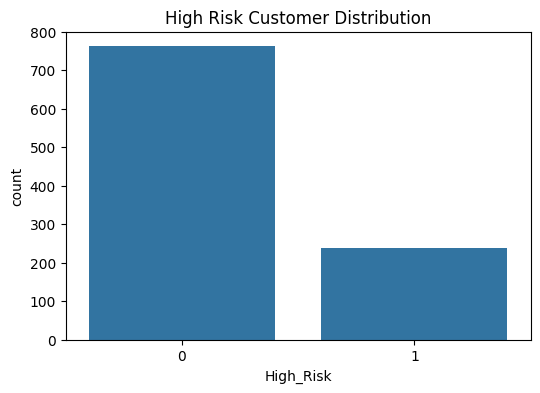

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="High_Risk"
)

plt.title(
    "High Risk Customer Distribution"
)

plt.savefig(
    "visuals/usecase2/risk_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [13]:
features = [
    "Debt_to_Income_Ratio",
    "Existing_EMIs",
    "CIBIL_Score",
    "Employment_Length_Years",
    "Annual_Household_Income",
    "Loan_to_Annual_Income"
]

X = df[features]

y = df["High_Risk"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print("Before SMOTE")

print(y_train.value_counts())

Before SMOTE
High_Risk
0    610
1    190
Name: count, dtype: int64


In [16]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [17]:
print("After SMOTE")

print(y_train_smote.value_counts())

After SMOTE
High_Risk
0    610
1    610
Name: count, dtype: int64


In [18]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    print(f"\n{model_name}")

    print(
        "Accuracy:",
        round(
            accuracy_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "F1 Score:",
        round(
            f1_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "\nClassification Report\n"
    )

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

In [19]:
lr_model = LogisticRegression()

lr_model.fit(
    X_train_smote,
    y_train_smote
)

lr_predictions = lr_model.predict(
    X_test
)

evaluate_model(
    "Logistic Regression",
    y_test,
    lr_predictions
)


Logistic Regression
Accuracy: 0.715
Precision: 0.4416
Recall: 0.7083
F1 Score: 0.544

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.72      0.79       152
           1       0.44      0.71      0.54        48

    accuracy                           0.71       200
   macro avg       0.66      0.71      0.67       200
weighted avg       0.78      0.71      0.73       200



In [44]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print(lr_accuracy)

0.715


In [20]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

rf_predictions = rf_model.predict(
    X_test
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)


Random Forest
Accuracy: 0.995
Precision: 1.0
Recall: 0.9792
F1 Score: 0.9895

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       152
           1       1.00      0.98      0.99        48

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



In [45]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(rf_accuracy)

0.995


In [21]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train_smote,
    y_train_smote
)

gb_predictions = gb_model.predict(
    X_test
)

evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_predictions
)


Gradient Boosting
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      1.00      1.00        48

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [46]:
gb_accuracy = accuracy_score(
    y_test,
    gb_predictions
)

print(gb_accuracy)

1.0


In [22]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

xgb_predictions = xgb_model.predict(
    X_test
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_predictions
)


XGBoost
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      1.00      1.00        48

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [47]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print(xgb_accuracy)

1.0


In [23]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, gb_predictions),
        accuracy_score(y_test, xgb_predictions)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,XGBoost,1.000
2,Gradient Boosting,1.000
1,Random Forest,0.995
0,Logistic Regression,0.715


In [24]:
params = {
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5, 7],
    "n_estimators": [100, 200],
    "subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train_smote,
    y_train_smote
)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
0.9975307809074042


In [35]:
best_predictions = best_model.predict(
    X_test
)

evaluate_model(
    "Tuned Risk Model",
    y_test,
    best_predictions
)


Tuned Risk Model
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      1.00      1.00        48

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



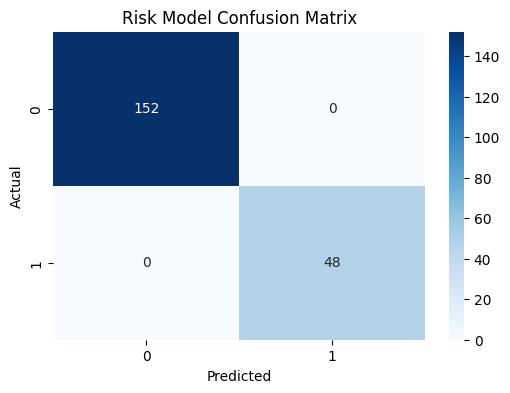

In [36]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Risk Model Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "visuals/usecase2/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [37]:
probabilities = best_model.predict_proba(
    X_test
)[:,1]

roc_score = roc_auc_score(
    y_test,
    probabilities
)

print(
    "ROC-AUC Score:",
    round(roc_score,4)
)

ROC-AUC Score: 1.0


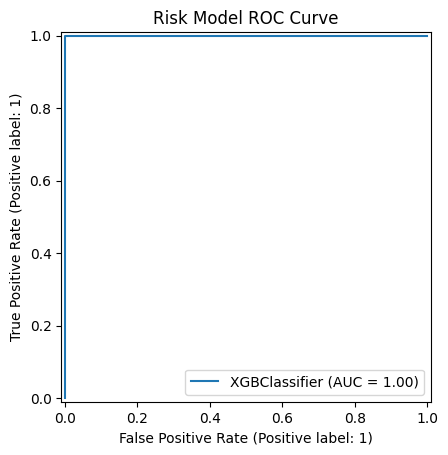

In [38]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title(
    "Risk Model ROC Curve"
)

plt.savefig(
    "visuals/usecase2/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

In [39]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
importance_df

,Feature,Importance
2,CIBIL_Score,0.505546
0,Debt_to_Income_Ratio,0.472170
5,Loan_to_Annual_Income,0.010664
1,Existing_EMIs,0.006270
4,Annual_Household_Income,0.005351
3,Employment_Length_Years,0.000000


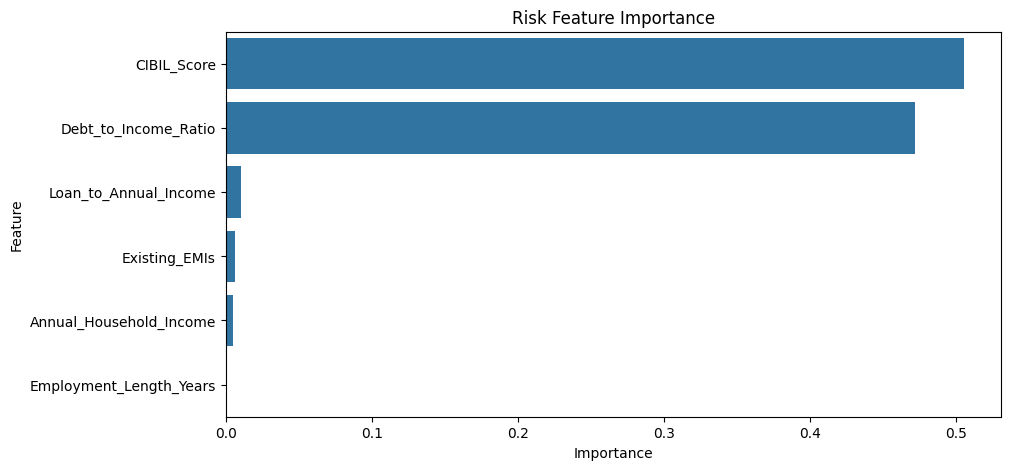

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Risk Feature Importance"
)

plt.savefig(
    "visuals/usecase2/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [48]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        gb_accuracy,
        xgb_accuracy
    ]
})

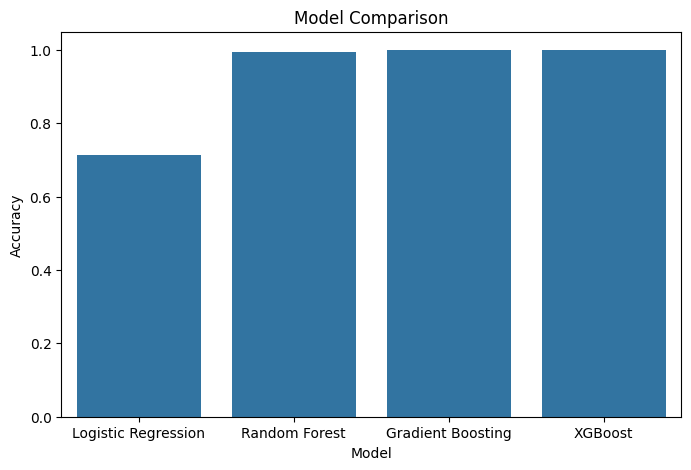

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Model Comparison"
)

plt.xticks(rotation=0)

plt.savefig(
    "visuals/usecase2/model_comparison.png",
    bbox_inches="tight"
)

plt.show()